### 04 — EDA & Feature Engineering: COICOP Panel (Inflation Categories)

**Goal.** Perform robust, non-redundant EDA on the COICOP-augmented quarterly master panel and engineer a clean, ML-ready feature table for later modeling.

**Scope.**
- Panel: `data_processed/master_quarterly_panel_coicop.parquet` (macro master + `hicpInflation_CP01` … `hicpInflation_CP12`).
- Geos: 36 countries/aggregates.
- Benchmarks: EU27 is the reference comparator; Germany (`DE`) is always spotlighted; `coreEuro` subset is used for readability (defined once and reused).

**Key EDA question (COICOP).**
- Which COICOP categories drove the post-2020 inflation surge across geographies, and how does each country differ vs the EU27 benchmark?

**Workflow rules.**
- One or two code cells per step; we only move forward after checking outputs.
- CamelCase for all variables.
- Plots follow the project plotting style guide: clear titles/units, no clutter, and we save both the figure and the underlying table only after the plot is confirmed correct.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

# Repro + display
randomSeed = 27
np.random.seed(randomSeed)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Paths (assumes notebook lives in /notebooks or project root; adjust only here)
rootPath = Path.cwd()
dataProcessedPath = rootPath / "data_processed"
reportsPath = rootPath / "reports"
figuresPath = reportsPath / "figures"
tablesPath = reportsPath / "tables"

figuresPath.mkdir(parents=True, exist_ok=True)
tablesPath.mkdir(parents=True, exist_ok=True)

# Plot defaults (project style guide-friendly baseline)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "figure.figsize": (10, 5.5),
    "axes.grid": True,
    "axes.titlepad": 10,
})


In [2]:
# --- Fix rootPath detection + enforce project seed ---
randomSeed = 27
np.random.seed(randomSeed)

cwdPath = Path.cwd().resolve()

rootPath = None
for p in [cwdPath] + list(cwdPath.parents)[:6]:
    if (p / "data_processed").exists():
        rootPath = p
        break

if rootPath is None:
    raise FileNotFoundError(
        f"Could not locate project root containing 'data_processed' starting from: {cwdPath}"
    )

dataProcessedPath = rootPath / "data_processed"
reportsPath = rootPath / "reports"
figuresPath = reportsPath / "figures"
tablesPath = reportsPath / "tables"

figuresPath.mkdir(parents=True, exist_ok=True)
tablesPath.mkdir(parents=True, exist_ok=True)

print("rootPath:", rootPath)
print("dataProcessedPath:", dataProcessedPath, "| exists:", dataProcessedPath.exists())
print("reportsPath:", reportsPath, "| exists:", reportsPath.exists())


rootPath: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income
dataProcessedPath: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_processed | exists: True
reportsPath: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports | exists: True


In [3]:
coicopPanelPath = dataProcessedPath / "master_quarterly_panel_coicop.parquet"
if not coicopPanelPath.exists():
    raise FileNotFoundError(f"Missing: {coicopPanelPath.resolve()}")

dfCoicop = pd.read_parquet(coicopPanelPath)

print("dfCoicop shape:", dfCoicop.shape)
print("Columns (first 30):", list(dfCoicop.columns)[:30])

# Identify key columns (expected from notebook 02)
keyCols = ["geo", "quantile", "indic_il", "currency", "timeQuarter"]
missingKeyCols = [c for c in keyCols if c not in dfCoicop.columns]
if missingKeyCols:
    raise ValueError(f"Missing expected key columns: {missingKeyCols}")

# Key uniqueness
dupN = dfCoicop.duplicated(keyCols).sum()
print("Duplicate key rows:", int(dupN))
assert dupN == 0, "Non-unique (geo, quantile, indic_il, currency, timeQuarter) keys."

# timeQuarter dtype check
print("timeQuarter dtype:", dfCoicop["timeQuarter"].dtype)
print("timeQuarter min/max:", dfCoicop["timeQuarter"].min(), "→", dfCoicop["timeQuarter"].max())

# Geos
uniqueGeos = sorted(dfCoicop["geo"].unique())
print("Unique geos:", len(uniqueGeos))
print("Sample geos:", uniqueGeos[:12], "...", uniqueGeos[-5:])

# Find EU27 aggregate robustly
eu27Candidates = [g for g in uniqueGeos if str(g).startswith("EU27")]
eu27Geo = eu27Candidates[0] if eu27Candidates else ("EU27" if "EU27" in uniqueGeos else None)
print("eu27Geo detected:", eu27Geo)

germanyGeo = "DE"
print("Germany present:", germanyGeo in uniqueGeos)

# COICOP inflation columns (should be CP01..CP12)
coicopInflCols = [c for c in dfCoicop.columns if c.startswith("hicpInflation_CP")]
print("COICOP inflation columns found:", len(coicopInflCols))
print(sorted(coicopInflCols))

# Month coverage flag (used in notebook 03 for high-confidence filter)
coverageCols = [c for c in ["hicpIndex_nMonths", "hicpInflation_nMonths", "hicp_nMonths_min"] if c in dfCoicop.columns]
print("Coverage cols present:", coverageCols)
if "hicp_nMonths_min" in dfCoicop.columns:
    print(dfCoicop["hicp_nMonths_min"].value_counts(dropna=False).sort_index())


dfCoicop shape: (108000, 24)
Columns (first 30): ['geo', 'quantile', 'indic_il', 'currency', 'timeQuarter', 'incomeValue', 'hicpIndex', 'hicpIndex_nMonths', 'hicpInflation', 'hicpInflation_nMonths', 'hicp_nMonths_min', 'employmentIndex', 'hicpInflation_CP01', 'hicpInflation_CP02', 'hicpInflation_CP03', 'hicpInflation_CP04', 'hicpInflation_CP05', 'hicpInflation_CP06', 'hicpInflation_CP07', 'hicpInflation_CP08', 'hicpInflation_CP09', 'hicpInflation_CP10', 'hicpInflation_CP11', 'hicpInflation_CP12']
Duplicate key rows: 0
timeQuarter dtype: period[Q-DEC]
timeQuarter min/max: 2000Q1 → 2024Q4
Unique geos: 36
Sample geos: ['AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EA', 'EA19', 'EA20', 'EE'] ... ['RS', 'SE', 'SI', 'SK', 'UK']
eu27Geo detected: EU27_2020
Germany present: True
COICOP inflation columns found: 12
['hicpInflation_CP01', 'hicpInflation_CP02', 'hicpInflation_CP03', 'hicpInflation_CP04', 'hicpInflation_CP05', 'hicpInflation_CP06', 'hicpInflation_CP07', 'hicpInflation_CP08', 'hi

In [4]:
# --- Notebook constants (define once) ---
notebookTag = "eda_coicop"
figuresDir = figuresPath / notebookTag
tablesDir = tablesPath / notebookTag
figuresDir.mkdir(parents=True, exist_ok=True)
tablesDir.mkdir(parents=True, exist_ok=True)

geoCol = "geo"
timeCol = "timeQuarter"
eu27Geo = "EU27_2020"
germanyGeo = "DE"

coreEuroGeos = ["DE", "FR", "IT", "ES", "NL", "UK", "PL", "SE"]  # from Notebook 03

aggGeos = ["EU27_2020", "EA", "EA19", "EA20"]
countryGeos = [g for g in uniqueGeos if g not in aggGeos]

crisisWindowsMain = {
    "GFC + Euro debt": ("2008Q3", "2012Q4"),
    "COVID": ("2020Q1", "2020Q2"),
    "Inflation surge": ("2021Q2", "2022Q4"),
}

print("figuresDir:", figuresDir)
print("tablesDir :", tablesDir)
print("EU27 geo  :", eu27Geo, "| present:", eu27Geo in uniqueGeos)
print("Germany   :", germanyGeo, "| present:", germanyGeo in uniqueGeos)
print("coreEuroGeos ok:", all(g in uniqueGeos for g in coreEuroGeos))
print("countryGeos:", len(countryGeos), "| aggGeos:", aggGeos)


figuresDir: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_coicop
tablesDir : /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_coicop
EU27 geo  : EU27_2020 | present: True
Germany   : DE | present: True
coreEuroGeos ok: True
countryGeos: 32 | aggGeos: ['EU27_2020', 'EA', 'EA19', 'EA20']


In [5]:
# --- Collapse to geo-quarter (COICOP inflations should not vary by quantile) ---
colsToCheck = ["hicpInflation", "hicpIndex", "employmentIndex"] + coicopInflCols
nuniqueByGeoQuarter = (
    dfCoicop.groupby([geoCol, timeCol])[colsToCheck]
    .nunique(dropna=False)
)

maxNunique = int(nuniqueByGeoQuarter.max().max())
print("Max nunique within (geo,timeQuarter) across quantiles:", maxNunique)
assert maxNunique == 1, "Some COICOP/macro values vary across quantiles — investigate before collapsing."

dfCoicopGq = (
    dfCoicop.sort_values([geoCol, timeCol])
    .drop_duplicates([geoCol, timeCol])
    [[geoCol, timeCol, "hicpInflation", "hicpIndex", "employmentIndex", "hicp_nMonths_min"] + coicopInflCols]
    .copy()
)

# High-confidence filter (same rule as macro notebook)
dfCoicopGqHq = dfCoicopGq.loc[dfCoicopGq["hicp_nMonths_min"] == 3].copy()

# Datetime column for plotting
dfCoicopGq["timeDt"] = dfCoicopGq[timeCol].dt.to_timestamp(how="end")
dfCoicopGqHq["timeDt"] = dfCoicopGqHq[timeCol].dt.to_timestamp(how="end")

print("dfCoicopGq   shape:", dfCoicopGq.shape)
print("dfCoicopGqHq shape:", dfCoicopGqHq.shape)
print("Rows per geo (dfCoicopGq):", dfCoicopGq[geoCol].value_counts().head(3).to_dict())


Max nunique within (geo,timeQuarter) across quantiles: 1
dfCoicopGq   shape: (3600, 19)
dfCoicopGqHq shape: (3523, 19)
Rows per geo (dfCoicopGq): {'AT': 100, 'BE': 100, 'IS': 100}


In [6]:
# --- Metadata paths ---
metadataPath = rootPath / "metadata"
coicopLabelsPath = metadataPath / "coicop_cp00_cp12_labels.tsv"
geoLabelsPath = metadataPath / "geo_labels_36.csv"

for p in [coicopLabelsPath, geoLabelsPath]:
    if not p.exists():
        raise FileNotFoundError(f"Missing metadata file: {p.resolve()}")

dfCoicopLabels = pd.read_csv(coicopLabelsPath, sep="\t")
dfGeoLabels = pd.read_csv(geoLabelsPath)

print("dfCoicopLabels shape:", dfCoicopLabels.shape)
print(dfCoicopLabels.head(3))

print("\ndfGeoLabels shape:", dfGeoLabels.shape)
print(dfGeoLabels.head(3))


dfCoicopLabels shape: (13, 2)
  coicop                                coicop_label
0   CP00                              All-items HICP
1   CP01            Food and non-alcoholic beverages
2   CP02  Alcoholic beverages, tobacco and narcotics

dfGeoLabels shape: (36, 2)
  geo geo_label
0  AT   Austria
1  BE   Belgium
2  BG  Bulgaria


In [7]:
# --- COICOP code -> label ---
coicopLabelByCode = dict(zip(dfCoicopLabels["coicop"], dfCoicopLabels["coicop_label"]))

# --- Geo -> label (robust: figure out column names) ---
geoKeyCol = "geo" if "geo" in dfGeoLabels.columns else dfGeoLabels.columns[0]
geoLabelCol = "label" if "label" in dfGeoLabels.columns else dfGeoLabels.columns[1]
geoLabelByGeo = dict(zip(dfGeoLabels[geoKeyCol], dfGeoLabels[geoLabelCol]))

# --- Column name -> nice COICOP label ---
# hicpInflation_CP01 -> "CP01 Food and non-alcoholic beverages"
coicopNiceLabelByCol = {}
for c in coicopInflCols:
    cpCode = c.split("_")[-1]  # "CP01"
    label = coicopLabelByCode.get(cpCode, cpCode)
    coicopNiceLabelByCol[c] = f"{cpCode} {label}"

print("Example mapping:", list(coicopNiceLabelByCol.items())[:3])
print("EU27 label:", geoLabelByGeo.get(eu27Geo, eu27Geo))
print("DE label  :", geoLabelByGeo.get(germanyGeo, germanyGeo))


Example mapping: [('hicpInflation_CP01', 'CP01 Food and non-alcoholic beverages'), ('hicpInflation_CP02', 'CP02 Alcoholic beverages, tobacco and narcotics'), ('hicpInflation_CP03', 'CP03 Clothing and footwear')]
EU27 label: European Union - 27 countries (from 2020)
DE label  : Germany


**3. COICOP drivers of the inflation surge (EU27 benchmark + Germany spotlight)**

**Question.** During the inflation surge (2021Q2–2022Q4), which COICOP categories show the highest inflation rates, and how does Germany differ from the EU27 benchmark?

**Operational definition.**
- Metric: average **YoY inflation rate** per COICOP category over 2021Q2–2022Q4.
- Data quality: restrict to quarters with `hicp_nMonths_min == 3` (high-confidence).
- Note: without COICOP weights, this is not a formal “contribution to headline” decomposition; it measures category-specific inflation intensity.


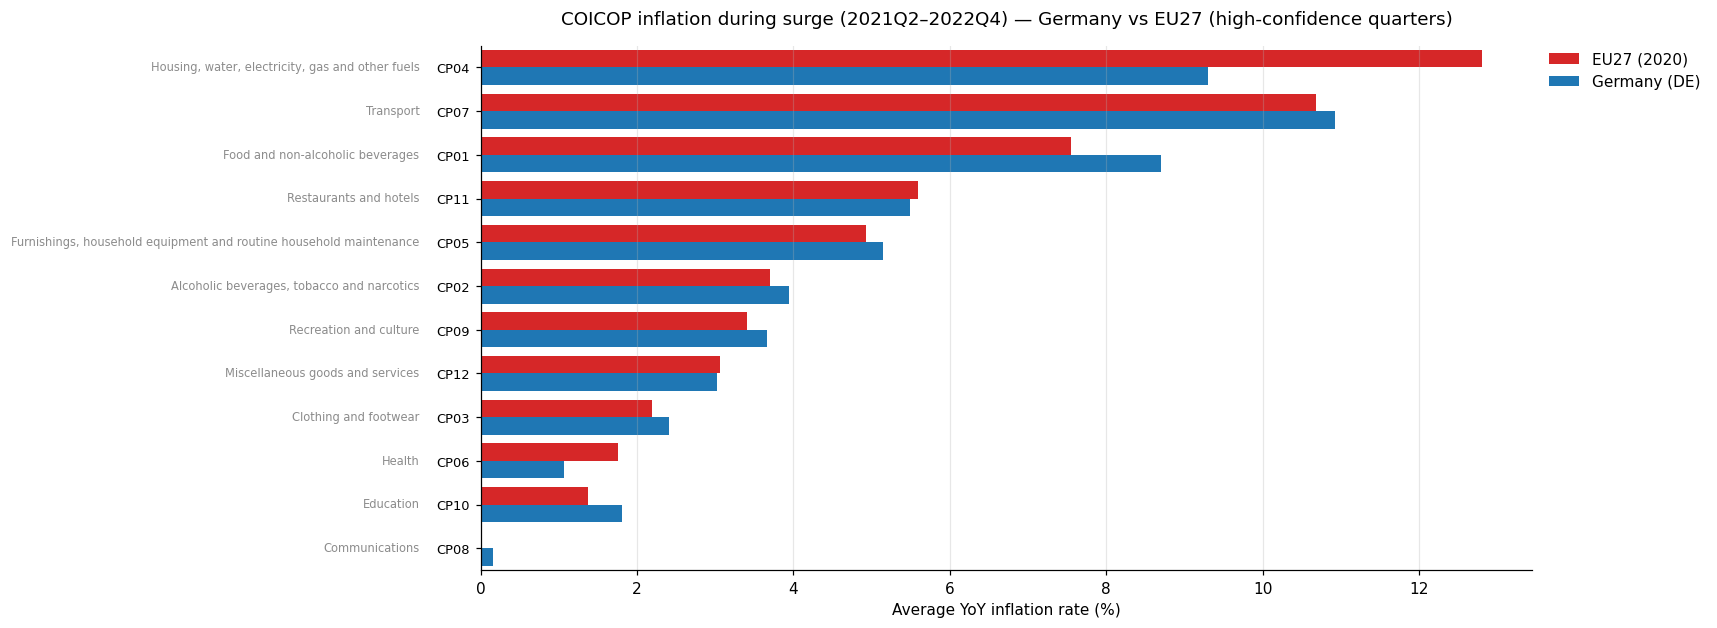

In [8]:
# --- Recompute plotDf ---
surgeStart = pd.Period("2021Q2", freq="Q-DEC")
surgeEnd = pd.Period("2022Q4", freq="Q-DEC")

dfSurge = dfCoicopGqHq.loc[
    (dfCoicopGqHq[timeCol] >= surgeStart) & (dfCoicopGqHq[timeCol] <= surgeEnd),
    [geoCol, timeCol] + coicopInflCols
].copy()

avgByGeo = dfSurge.groupby(geoCol)[coicopInflCols].mean()
avgEu27 = avgByGeo.loc[eu27Geo]
avgDe = avgByGeo.loc[germanyGeo]

plotDf = pd.DataFrame({"EU27": avgEu27, "Germany": avgDe}).sort_values("EU27", ascending=False)

cpCodes = [c.split("_")[-1] for c in plotDf.index]
cpDescs = [coicopLabelByCode.get(cp, cp) for cp in cpCodes]
y = np.arange(len(plotDf))

# --- Layout: more horizontal space for bars ---
fig = plt.figure(figsize=(15.5, 5.6), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.25, 3.25], wspace=0.02)

axLab = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[0, 1], sharey=axLab)

# Left label column (smaller + faded)
axLab.set_xlim(0, 1)
axLab.set_ylim(-0.5, len(y) - 0.5)
for yi, txt in zip(y, cpDescs):
    axLab.text(
        1.0, yi, txt,
        ha="right", va="center",
        fontsize=7.5, color="0.55"
    )
axLab.axis("off")

# Bars (DE blue, EU red)
barH = 0.40
ax.barh(y - barH/2, plotDf["EU27"].values, height=barH, label="EU27 (2020)", color="tab:red")
ax.barh(y + barH/2, plotDf["Germany"].values, height=barH, label="Germany (DE)", color="tab:blue")

ax.set_yticks(y)
ax.set_yticklabels(cpCodes, fontsize=8.5)
ax.invert_yaxis()

ax.set_xlabel("Average YoY inflation rate (%)")
ax.set_title("COICOP inflation during surge (2021Q2–2022Q4) — Germany vs EU27 (high-confidence quarters)", pad=14)

ax.grid(True, axis="x", alpha=0.30)
ax.grid(False, axis="y")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

# Legend OUTSIDE (top-right) so it never overlaps title
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1.00),
    borderaxespad=0.0
)



Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_coicop/coicop_surge_avgYoY_DE_vs_EU27_2021Q2_2022Q4.png
Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_coicop/coicop_surge_avgYoY_DE_vs_EU27_2021Q2_2022Q4.csv


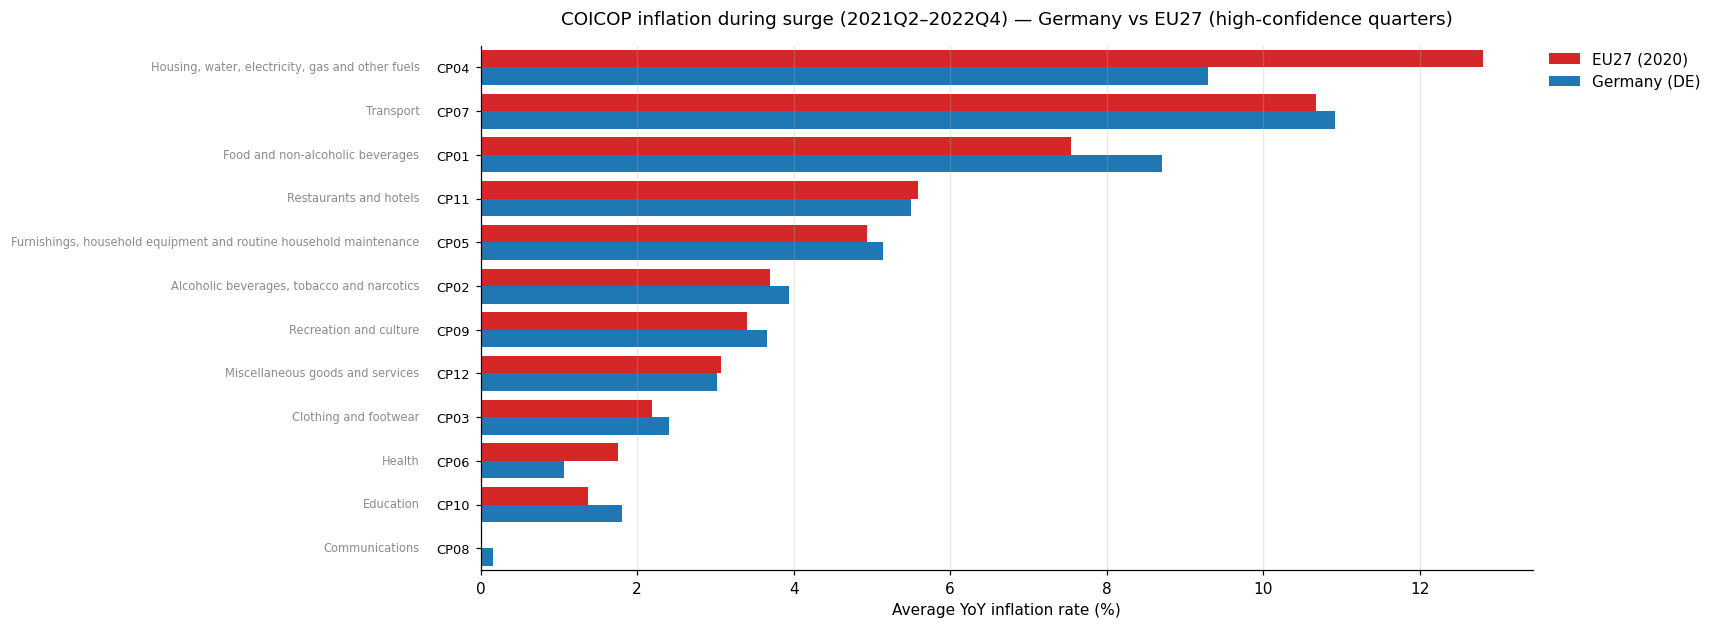

In [9]:
# Save table (data behind the plot)
plotTable = plotDf.copy()
plotTable.index.name = "coicopCol"
plotTable["coicopCode"] = [c.split("_")[-1] for c in plotTable.index]
plotTable["coicopLabel"] = [coicopLabelByCode.get(code, code) for code in plotTable["coicopCode"]]
plotTable = plotTable[["coicopCode", "coicopLabel", "EU27", "Germany"]].reset_index(drop=True)

tablePath = tablesDir / "coicop_surge_avgYoY_DE_vs_EU27_2021Q2_2022Q4.csv"
plotTable.to_csv(tablePath, index=False)

# Save figure (re-render same plot for consistent saving)
figPath = figuresDir / "coicop_surge_avgYoY_DE_vs_EU27_2021Q2_2022Q4.png"

fig = plt.figure(figsize=(15.5, 5.6), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.25, 3.25], wspace=0.02)

axLab = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[0, 1], sharey=axLab)

y = np.arange(len(plotDf))
cpCodes = [c.split("_")[-1] for c in plotDf.index]
cpDescs = [coicopLabelByCode.get(cp, cp) for cp in cpCodes]

axLab.set_xlim(0, 1)
axLab.set_ylim(-0.5, len(y) - 0.5)
for yi, txt in zip(y, cpDescs):
    axLab.text(1.0, yi, txt, ha="right", va="center", fontsize=7.5, color="0.55")
axLab.axis("off")

barH = 0.40
ax.barh(y - barH/2, plotDf["EU27"].values, height=barH, label="EU27 (2020)", color="tab:red")
ax.barh(y + barH/2, plotDf["Germany"].values, height=barH, label="Germany (DE)", color="tab:blue")

ax.set_yticks(y)
ax.set_yticklabels(cpCodes, fontsize=8.5)
ax.invert_yaxis()

ax.set_xlabel("Average YoY inflation rate (%)")
ax.set_title("COICOP inflation during surge (2021Q2–2022Q4) — Germany vs EU27 (high-confidence quarters)", pad=14)

ax.grid(True, axis="x", alpha=0.30)
ax.grid(False, axis="y")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.00), borderaxespad=0.0)

fig.savefig(figPath, bbox_inches="tight")
print("Saved:", figPath)
print("Saved:", tablePath)


- **How to read this chart**
  - Each row is a COICOP category (CP01–CP12). Bars show the **average year-on-year inflation rate** during **2021Q2–2022Q4** (high-confidence quarters only).
  - **EU27 (red)** is the benchmark; **Germany (blue)** is compared against it. Larger bars = stronger inflation pressure in that category.

- **What stands out economically**
  - The surge is dominated by **CP04 Housing/energy-related** inflation at EU27 level, consistent with the Europe-wide energy shock.
  - Germany is **higher than EU27** in categories like **CP07 Transport** and **CP01 Food**, aligning with post-COVID reopening frictions and the later energy/commodity pass-through.
  - Services-linked categories like **CP11 Restaurants & hotels** are elevated for both, reflecting reopening demand and wage/cost pressures.
  - Very low inflation in **CP08 Communications** is a useful “control category”: it did not materially participate in the surge.

- **Macro context (interpretation, not causal proof)**
  - This period captures the **post-COVID reopening** phase and the **2022 energy/commodity shock** (including the Russia–Ukraine war channel), which disproportionately affects energy-intensive and tradable categories.
  - Without COICOP expenditure weights, this figure measures **inflation intensity by category**, not exact contribution to headline inflation.

- **What “YoY” means with quarterly data**
  - “YoY” (year-on-year) compares a quarter to the **same quarter one year earlier** (i.e., **4 quarters back**).
  - Example pairings: 2022Q2 vs 2021Q2, 2022Q1 vs 2021Q1, 2021Q4 vs 2020Q4.

- **Formula (quarterly YoY inflation)**
  - Let $I_{g,c,t}$ be the HICP index for geography $g$, COICOP category $c$, and quarter $t$.
  - The quarterly year-on-year inflation rate is:

    $$
    \pi^{\text{YoY}}_{g,c,t}
    = 100 \times \left(\frac{I_{g,c,t}}{I_{g,c,t-4}} - 1\right)
    $$

  - In this figure, each bar is the **average** of $\pi^{\text{YoY}}_{g,c,t}$ over $t \in \{2021\text{Q}2,\ldots,2022\text{Q}4\}$ (high-confidence quarters only).

- **Interpreting the x-axis**
  - $0\%$ on the x-axis means $I_{g,c,t} = I_{g,c,t-4}$: prices are unchanged vs the same quarter last year.
  - Positive values mean inflation; negative values mean deflation.


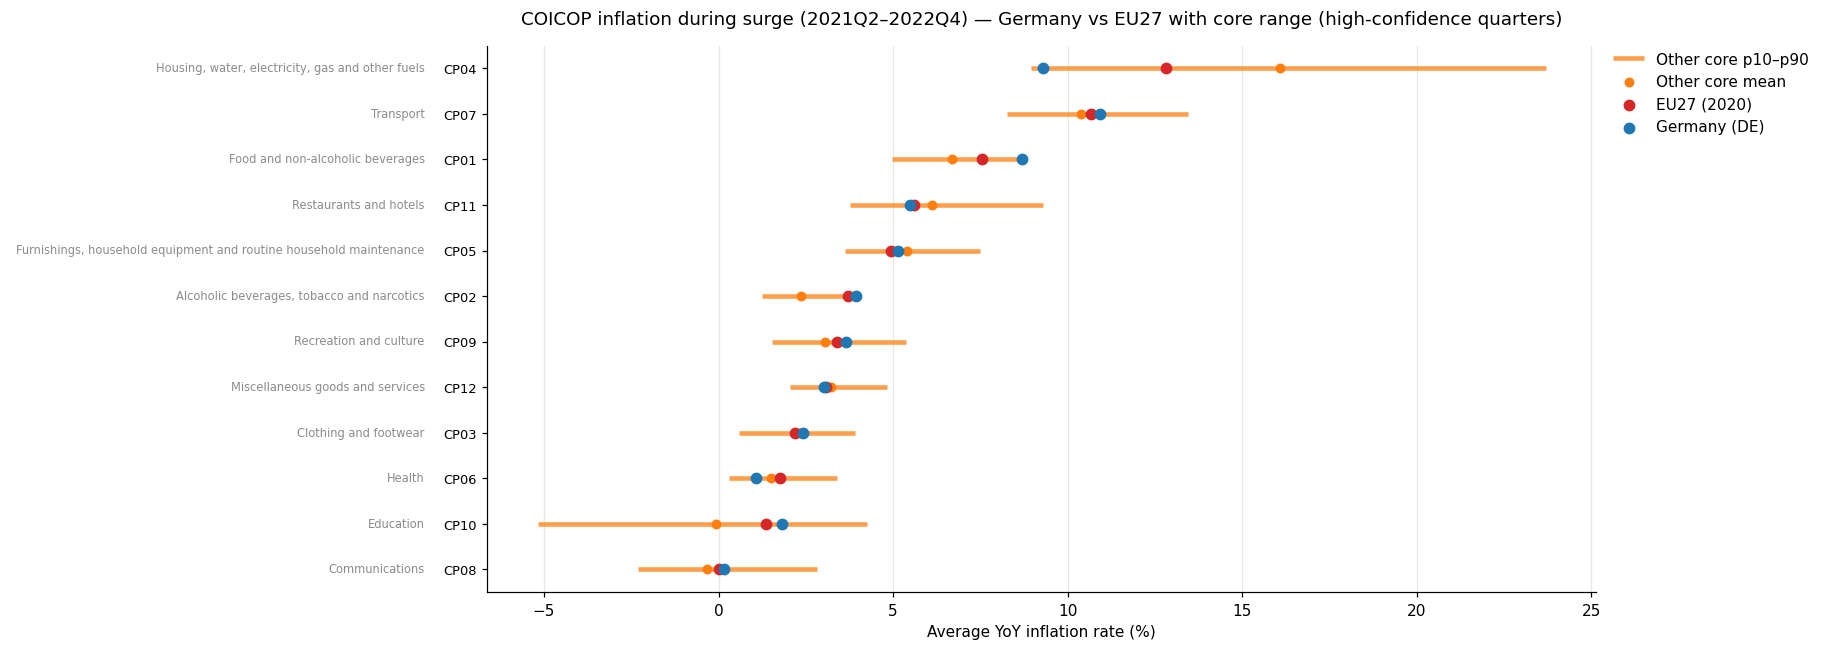

In [10]:
# --- Window ---
surgeStart = pd.Period("2021Q2", freq="Q-DEC")
surgeEnd = pd.Period("2022Q4", freq="Q-DEC")

# --- Core set (UK removed) ---
coreGeos = ["DE", "FR", "IT", "ES", "NL", "PL", "SE"]
otherCoreGeos = [g for g in coreGeos if g != germanyGeo]

dfSurge = dfCoicopGqHq.loc[
    (dfCoicopGqHq[timeCol] >= surgeStart) & (dfCoicopGqHq[timeCol] <= surgeEnd) &
    (dfCoicopGqHq[geoCol].isin(coreGeos + [eu27Geo])),
    [geoCol, timeCol] + coicopInflCols
].copy()

avgByGeo = dfSurge.groupby(geoCol)[coicopInflCols].mean()

# Safety checks
for g in [eu27Geo, germanyGeo] + otherCoreGeos:
    if g not in avgByGeo.index:
        raise ValueError(f"Missing geo in surge subset: {g}")

# Build summary table by category
rows = []
for c in coicopInflCols:
    cpCode = c.split("_")[-1]
    otherVals = avgByGeo.loc[otherCoreGeos, c].astype(float)

    rows.append({
        "coicopCol": c,
        "coicopCode": cpCode,
        "coicopLabel": coicopLabelByCode.get(cpCode, cpCode),
        "eu27": float(avgByGeo.loc[eu27Geo, c]),
        "de": float(avgByGeo.loc[germanyGeo, c]),
        "coreMean": float(otherVals.mean()),
        "coreP10": float(otherVals.quantile(0.10)),
        "coreP90": float(otherVals.quantile(0.90)),
    })

plotCoreDf = pd.DataFrame(rows).set_index("coicopCol")

# Sort by EU27 (descending)
plotCoreDf = plotCoreDf.sort_values("eu27", ascending=False)

# --- Two-column layout: left = label, right = plot ---
cpCodes = plotCoreDf["coicopCode"].tolist()
cpDescs = plotCoreDf["coicopLabel"].tolist()
y = np.arange(len(plotCoreDf))

fig = plt.figure(figsize=(16.5, 5.8), constrained_layout=True)
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.25, 3.35], wspace=0.02)

axLab = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[0, 1], sharey=axLab)

# Left column labels (small + faded)
axLab.set_xlim(0, 1)
axLab.set_ylim(-0.5, len(y) - 0.5)
for yi, txt in zip(y, cpDescs):
    axLab.text(1.0, yi, txt, ha="right", va="center", fontsize=7.5, color="0.55")
axLab.axis("off")

# Core range (p10–p90) and mean
ax.hlines(
    y=y,
    xmin=plotCoreDf["coreP10"].values,
    xmax=plotCoreDf["coreP90"].values,
    color="tab:orange",
    linewidth=3,
    alpha=0.75,
    label="Other core p10–p90"
)
ax.scatter(
    plotCoreDf["coreMean"].values, y,
    color="tab:orange", s=30, zorder=3,
    label="Other core mean"
)

# EU27 and Germany overlays
ax.scatter(plotCoreDf["eu27"].values, y, color="tab:red", s=45, zorder=4, label="EU27 (2020)")
ax.scatter(plotCoreDf["de"].values, y, color="tab:blue", s=45, zorder=5, label="Germany (DE)")

ax.set_yticks(y)
ax.set_yticklabels(cpCodes, fontsize=8.5)
ax.invert_yaxis()

ax.set_xlabel("Average YoY inflation rate (%)")
ax.set_title(
    "COICOP inflation during surge (2021Q2–2022Q4) — Germany vs EU27 with core range (high-confidence quarters)",
    pad=14
)

ax.grid(True, axis="x", alpha=0.30)
ax.grid(False, axis="y")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

# Legend outside (right)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1.00), borderaxespad=0.0)

plt.show()


In [11]:
# --- Save table behind the "core range" plot ---
coreRangeTable = plotCoreDf.reset_index().rename(columns={"index": "coicopCol"})
coreRangeTable = coreRangeTable[[
    "coicopCol", "coicopCode", "coicopLabel", "eu27", "de", "coreMean", "coreP10", "coreP90"
]]

tablePath = tablesDir / "coicop_surge_avgYoY_coreRange_DE_EU27_2021Q2_2022Q4.csv"
coreRangeTable.to_csv(tablePath, index=False)

# --- Save the already-rendered figure (no re-render) ---
figPath = figuresDir / "coicop_surge_avgYoY_coreRange_DE_EU27_2021Q2_2022Q4.png"
fig.savefig(figPath, bbox_inches="tight")

print("Saved:", figPath)
print("Saved:", tablePath)


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_coicop/coicop_surge_avgYoY_coreRange_DE_EU27_2021Q2_2022Q4.png
Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_coicop/coicop_surge_avgYoY_coreRange_DE_EU27_2021Q2_2022Q4.csv


- **How to read this chart**
  - Each row is a COICOP category (CP code shown; description on the left).
  - **Orange segment** = the **p10–p90 range** of average inflation across the **other core geos** (FR, IT, ES, NL, PL, SE) during 2021Q2–2022Q4.
  - **Orange dot** = mean of the other core geos.
  - **Red dot** = EU27 benchmark; **blue dot** = Germany.

- **What this tells us (economist interpretation)**
  - Categories with a **wide orange range** indicate **heterogeneous inflation pressure** across major European economies (country-specific exposure, policy pass-through, energy mix, etc.).
  - If **Germany (blue)** lies **above the orange band**, Germany is unusually high vs its peer core group; **below** implies unusually mild inflation for that category.
  - The pattern is consistent with post-COVID reopening dynamics plus the 2022 energy/commodity shock (including the Russia–Ukraine war channel), which tends to widen cross-country dispersion especially in energy- and transport-linked categories.

- **Technical note**
  - Values are **average YoY inflation rates** (quarter \(t\) compared to \(t-4\)), not weighted contributions to headline inflation.


In [12]:
# --- Surge window (primary) ---
surgeStart = pd.Period("2021Q2", freq="Q-DEC")
surgeEnd = pd.Period("2022Q4", freq="Q-DEC")

dfSurgeAll = dfCoicopGqHq.loc[
    (dfCoicopGqHq[timeCol] >= surgeStart) &
    (dfCoicopGqHq[timeCol] <= surgeEnd),
    [geoCol, timeCol] + coicopInflCols
].copy()

avgByGeoAll = dfSurgeAll.groupby(geoCol)[coicopInflCols].mean()

# Use countries only (exclude aggregates) for best/worst rankings
aggGeos = ["EU27_2020", "EA", "EA19", "EA20"]
countryGeos = [g for g in avgByGeoAll.index.tolist() if g not in aggGeos]

if eu27Geo not in avgByGeoAll.index:
    raise ValueError(f"EU27 not found: {eu27Geo}")

eu27Vec = avgByGeoAll.loc[eu27Geo]
deltaVsEu27 = avgByGeoAll.loc[countryGeos].subtract(eu27Vec, axis=1)  # (geo - EU27) in pp

# Rank categories by EU27 average inflation during surge (top 6 for plotting)
eu27Rank = eu27Vec.sort_values(ascending=False)
top6Cols = eu27Rank.index[:6].tolist()

print("Top 6 categories by EU27 surge inflation:")
for c in top6Cols:
    cp = c.split("_")[-1]
    print(f"  {cp}: {coicopLabelByCode.get(cp, cp)} | EU27 avg YoY = {eu27Vec[c]:.2f}%")

# Precompute best/worst 3 per category (for ALL 12 categories; we'll plot top 6)
extremeRows = []
for c in coicopInflCols:
    s = deltaVsEu27[c].dropna().sort_values()
    worst3 = s.head(3)
    best3 = s.tail(3)

    cp = c.split("_")[-1]
    label = coicopLabelByCode.get(cp, cp)

    for geo, val in worst3.items():
        extremeRows.append({"coicopCol": c, "coicopCode": cp, "coicopLabel": label, "geo": geo, "deltaPp": float(val), "side": "worst"})
    for geo, val in best3.items():
        extremeRows.append({"coicopCol": c, "coicopCode": cp, "coicopLabel": label, "geo": geo, "deltaPp": float(val), "side": "best"})

extremesDf = pd.DataFrame(extremeRows)
print("\nExtremes table shape:", extremesDf.shape)
display(extremesDf.query("coicopCol in @top6Cols").sort_values(["coicopCol", "side", "deltaPp"]))


Top 6 categories by EU27 surge inflation:
  CP04: Housing, water, electricity, gas and other fuels | EU27 avg YoY = 12.80%
  CP07: Transport | EU27 avg YoY = 10.68%
  CP01: Food and non-alcoholic beverages | EU27 avg YoY = 7.54%
  CP11: Restaurants and hotels | EU27 avg YoY = 5.59%
  CP05: Furnishings, household equipment and routine household maintenance | EU27 avg YoY = 4.93%
  CP02: Alcoholic beverages, tobacco and narcotics | EU27 avg YoY = 3.70%

Extremes table shape: (72, 6)


,coicopCol,coicopCode,coicopLabel,geo,deltaPp,side
3,hicpInflation_CP01,CP01,Food and non-alcoholic beverages,BG,6.2810,best
4,hicpInflation_CP01,CP01,Food and non-alcoholic beverages,LT,9.0429,best
5,hicpInflation_CP01,CP01,Food and non-alcoholic beverages,HU,9.7571,best
0,hicpInflation_CP01,CP01,Food and non-alcoholic beverages,CH,-7.5048,worst
1,hicpInflation_CP01,CP01,Food and non-alcoholic beverages,NO,-5.0381,worst
2,hicpInflation_CP01,CP01,Food and non-alcoholic beverages,IE,-3.5286,worst
9,hicpInflation_CP02,CP02,"Alcoholic beverages, tobacco and narcotics",CZ,3.1619,best
10,hicpInflation_CP02,CP02,"Alcoholic beverages, tobacco and narcotics",SK,3.6810,best
11,hicpInflation_CP02,CP02,"Alcoholic beverages, tobacco and narcotics",HU,6.7810,best
6,hicpInflation_CP02,CP02,"Alcoholic beverages, tobacco and narcotics",EL,-3.3048,worst


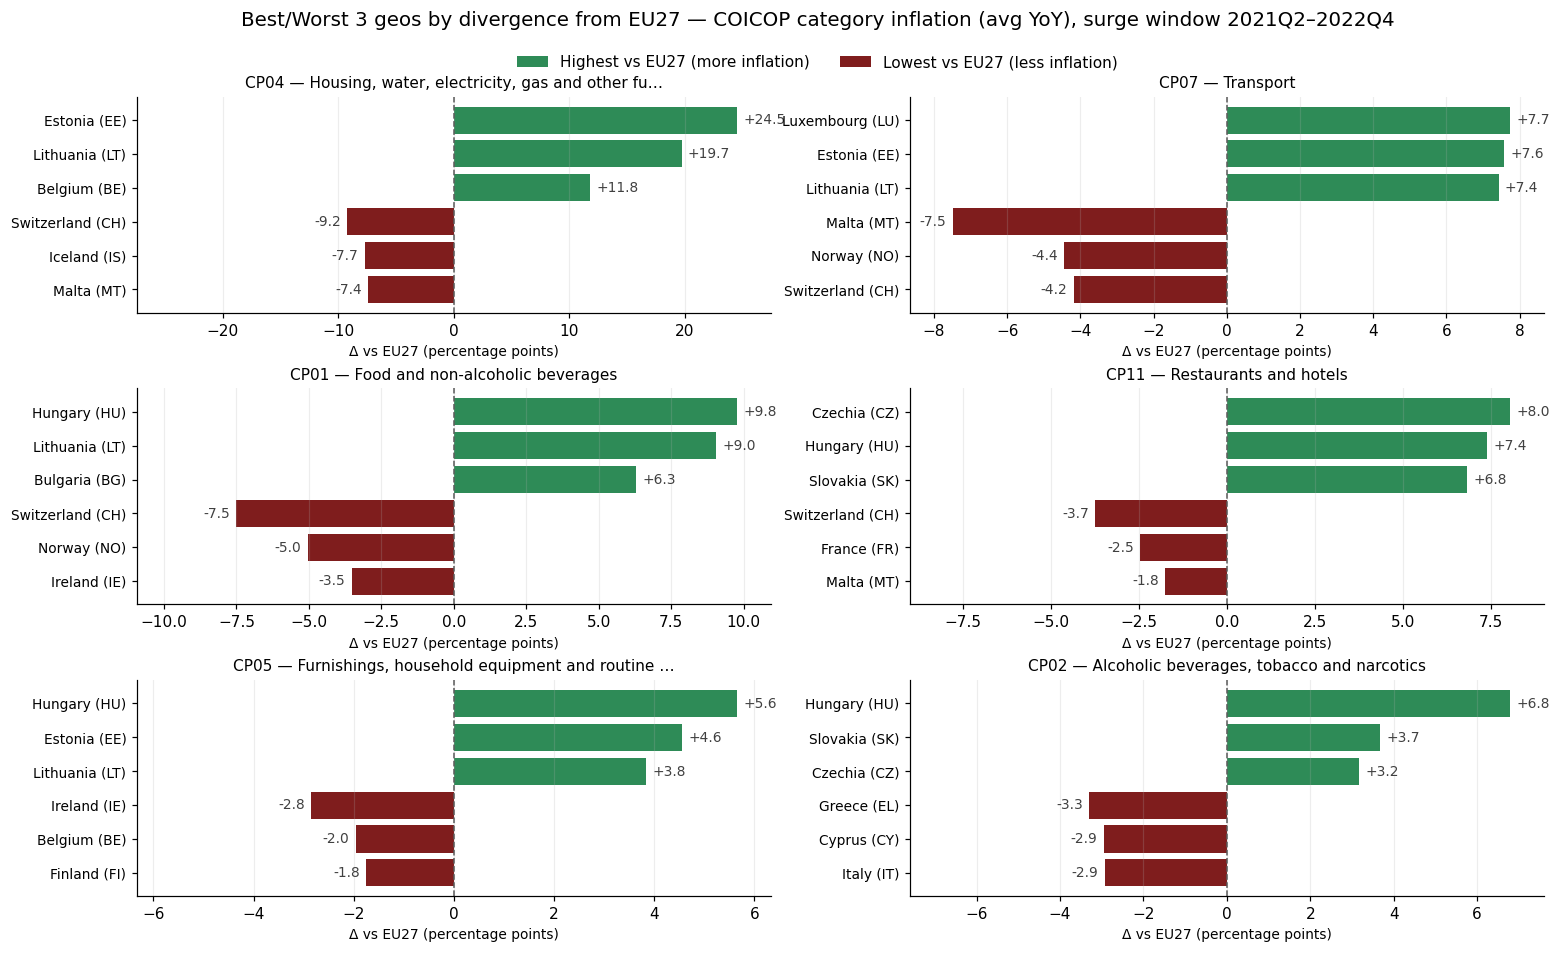

In [13]:
def shortText(s: str, maxLen: int = 46) -> str:
    return s if len(s) <= maxLen else (s[: maxLen - 1] + "…")

bestColor = "seagreen"
worstColor = "#7f1d1d"

fig, axes = plt.subplots(3, 2, figsize=(16.5, 9.2))
axes = axes.flatten()

for ax, c in zip(axes, top6Cols):
    dfCat = extremesDf.loc[extremesDf["coicopCol"] == c].copy()

    bestDf = dfCat.loc[dfCat["side"] == "best"].sort_values("deltaPp", ascending=False)
    worstDf = dfCat.loc[dfCat["side"] == "worst"].sort_values("deltaPp", ascending=True)
    dfPlot = pd.concat([bestDf, worstDf], ignore_index=True)

    def geoName(g):
        return f"{geoLabelByGeo.get(g, g)} ({g})" if geoLabelByGeo.get(g, g) != g else g

    yLabels = [geoName(g) for g in dfPlot["geo"].tolist()]
    y = np.arange(len(dfPlot))
    colors = [bestColor if s == "best" else worstColor for s in dfPlot["side"].tolist()]

    ax.barh(y, dfPlot["deltaPp"].values, color=colors)
    ax.axvline(0, color="0.35", linestyle="--", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(yLabels, fontsize=9)
    ax.invert_yaxis()

    cpCode = c.split("_")[-1]
    cpLabel = coicopLabelByCode.get(cpCode, cpCode)
    ax.set_title(f"{cpCode} — {shortText(cpLabel)}", fontsize=10, pad=6)

    # Symmetric x-limits
    minV = float(dfPlot["deltaPp"].min())
    maxV = float(dfPlot["deltaPp"].max())
    pad = 0.12 * (max(abs(minV), abs(maxV)) + 1e-9)
    lim = max(abs(minV), abs(maxV)) + pad
    ax.set_xlim(-lim, lim)

    ax.grid(True, axis="x", alpha=0.22)
    ax.grid(False, axis="y")
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

    ax.set_xlabel("Δ vs EU27 (percentage points)", fontsize=9)

    # Value labels
    for yi, val in zip(y, dfPlot["deltaPp"].values):
        ax.text(
            val + (0.02 * lim if val >= 0 else -0.02 * lim),
            yi,
            f"{val:+.1f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9,
            color="0.25",
        )

# Figure-level title + reserved top space for legend
fig.suptitle(
    "Best/Worst 3 geos by divergence from EU27 — COICOP category inflation (avg YoY), surge window 2021Q2–2022Q4",
    fontsize=13,
    y=0.985
)

# Legend (top center, outside panels)
handles = [
    Patch(facecolor=bestColor, label="Highest vs EU27 (more inflation)"),
    Patch(facecolor=worstColor, label="Lowest vs EU27 (less inflation)"),
]
fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.955))

# More breathing room between panels + keep space for title/legend
fig.subplots_adjust(top=0.90, hspace=0.35, wspace=0.22)

plt.show()


- Each panel shows the **3 countries with the highest** and the **3 with the lowest** average inflation in that category **relative to EU27**, during 2021Q2–2022Q4.
- The x-axis is $\Delta = \bar{\pi}_{\text{geo}} - \bar{\pi}_{\text{EU27}}$ in **percentage points**.
  - **Positive $\Delta$** means the country had **higher inflation than EU27** in that category (more inflation pressure).
  - **Negative $\Delta$** means the country had **lower inflation than EU27** in that category (less inflation pressure).
- “Less inflation” isn’t automatically “better” (it can reflect subsidies/price controls, different energy exposure, tax policy, etc.), so interpret $\Delta$ as **divergence** rather than welfare.


In [14]:
# Save figure (already rendered)
figPath = figuresDir / "coicop_outliers_top6_deltaVsEU27_surge_2021Q2_2022Q4.png"
fig.savefig(figPath, bbox_inches="tight")
print("Saved:", figPath)

# Save table: top-6 only (the exact content behind the plotted panels)
outliersTop6Table = (
    extremesDf.loc[extremesDf["coicopCol"].isin(top6Cols)]
    .copy()
    .sort_values(["coicopCol", "side", "deltaPp"], ascending=[True, True, True])
)

# Add readable labels
outliersTop6Table["geoLabel"] = outliersTop6Table["geo"].map(lambda g: geoLabelByGeo.get(g, g))
outliersTop6Table = outliersTop6Table[["coicopCol", "coicopCode", "coicopLabel", "geo", "geoLabel", "deltaPp", "side"]]

tablePath = tablesDir / "coicop_outliers_top6_deltaVsEU27_surge_2021Q2_2022Q4.csv"
outliersTop6Table.to_csv(tablePath, index=False)
print("Saved:", tablePath)


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_coicop/coicop_outliers_top6_deltaVsEU27_surge_2021Q2_2022Q4.png
Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/eda_coicop/coicop_outliers_top6_deltaVsEU27_surge_2021Q2_2022Q4.csv


- **What this figure shows**
  - For each selected COICOP category (top-6 by EU27 surge inflation), we plot the **3 countries with the highest** and **3 with the lowest** average inflation **relative to EU27** during 2021Q2–2022Q4.
  - The x-axis is the divergence in percentage points.

$$
\Delta_{\text{geo},c}
=
\overline{\pi^{\text{YoY}}_{\text{geo},c}}
-
\overline{\pi^{\text{YoY}}_{\text{EU27},c}}
$$

  - The overline denotes the average over the surge window.

- **How to interpret the sign**
  - **Positive $\Delta$ (green)** = that country had **higher inflation than EU27** in that category (more inflation pressure).
  - **Negative $\Delta$ (maroon)** = that country had **lower inflation than EU27** in that category (less inflation pressure).

- **Economic interpretation (what to look for)**
  - Categories like **CP04 (housing/energy)** tend to show the largest cross-country spreads, consistent with heterogeneous exposure to the energy shock, policy mitigation (subsidies/caps), and pass-through differences.
  - Repeated appearances of the same countries across panels suggest **systematic drivers** (energy mix, regulation, indirect taxes, wage-setting, market structure) rather than one-off noise.
  - “Lower inflation” is not automatically “better” (it may reflect subsidies/price controls or different measurement/policy), so treat $\Delta$ as **divergence from the EU benchmark**, not welfare.


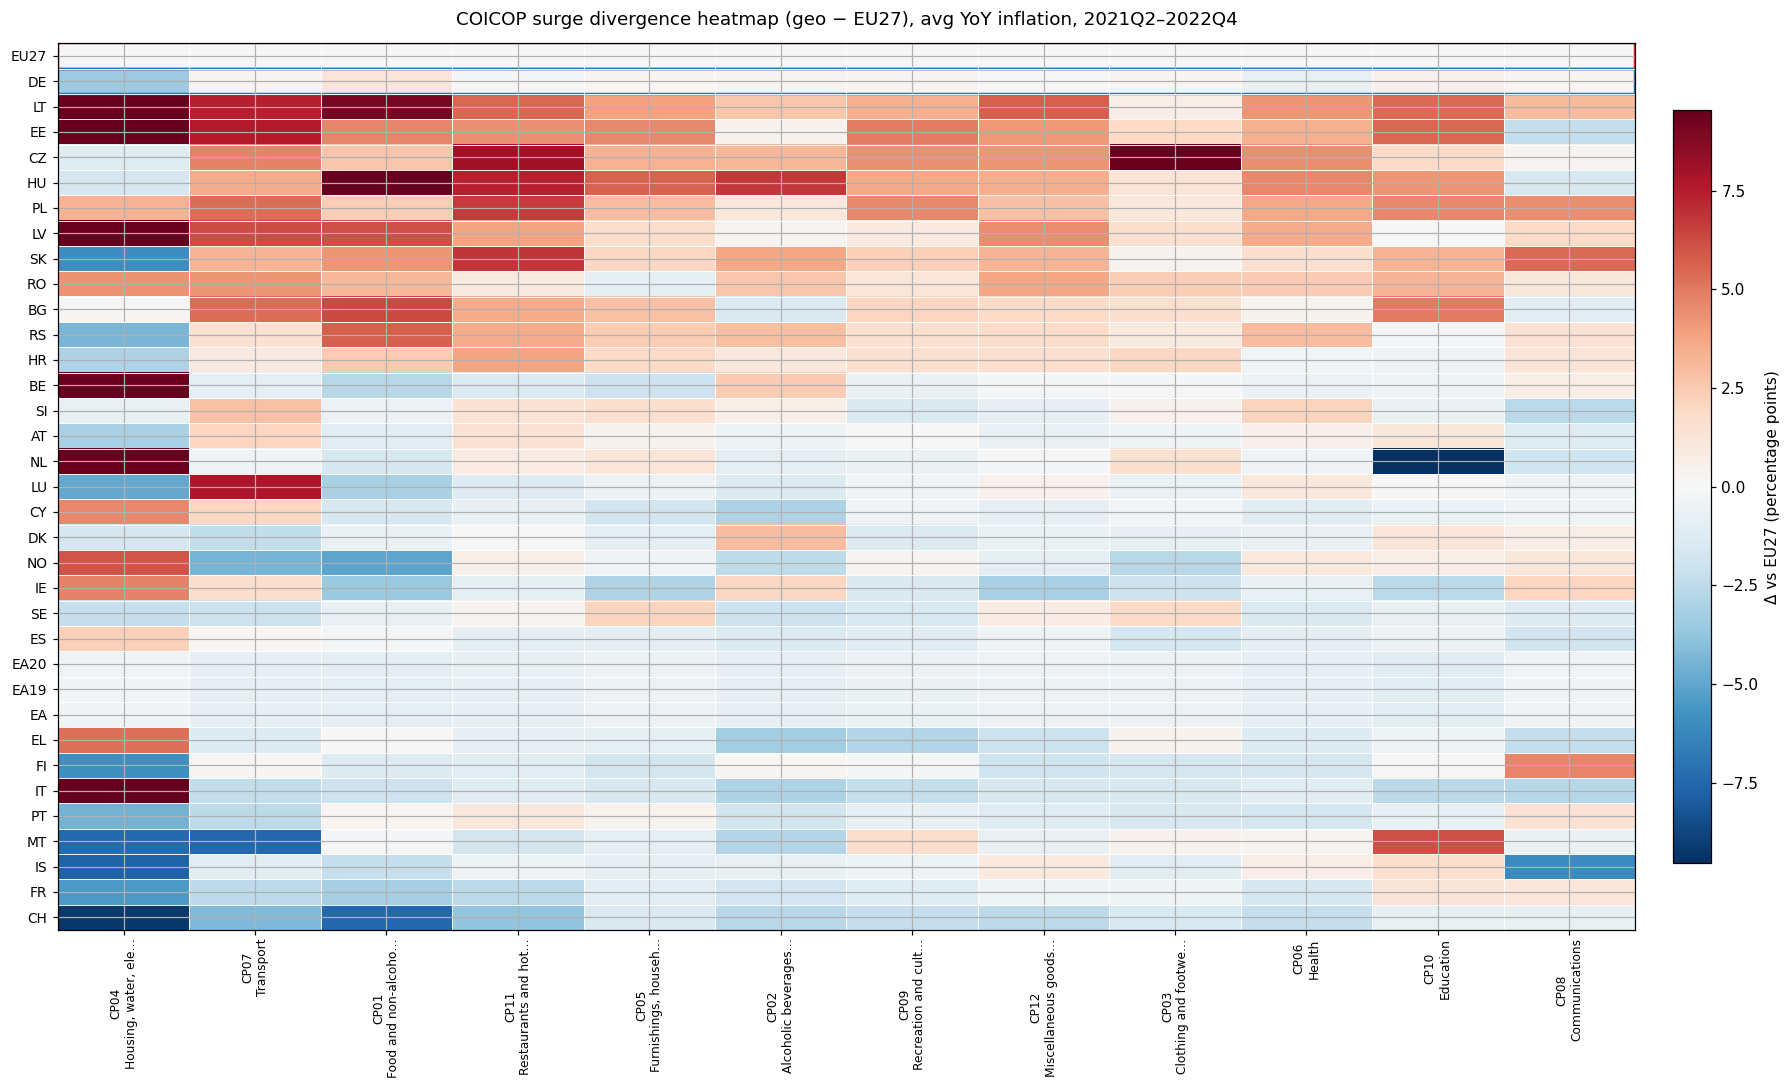

In [15]:
# --- Surge window (primary) ---
surgeStart = pd.Period("2021Q2", freq="Q-DEC")
surgeEnd   = pd.Period("2022Q4", freq="Q-DEC")

dfSurgeAll = dfCoicopGqHq.loc[
    (dfCoicopGqHq[timeCol] >= surgeStart) & (dfCoicopGqHq[timeCol] <= surgeEnd),
    [geoCol, timeCol] + coicopInflCols
].copy()

avgByGeo = dfSurgeAll.groupby(geoCol)[coicopInflCols].mean()

if eu27Geo not in avgByGeo.index:
    raise ValueError(f"EU27 not found in data: {eu27Geo}")

eu27Vec = avgByGeo.loc[eu27Geo]
deltaVsEu27All = avgByGeo.subtract(eu27Vec, axis=1)  # geo - EU27 (pp)

# Column order: highest EU27 category inflation first
colOrder = eu27Vec.sort_values(ascending=False).index.tolist()

# Row order: EU27 first, Germany second, then others by mean Δ
rowScore = deltaVsEu27All[colOrder].mean(axis=1)
otherRows = [g for g in rowScore.sort_values(ascending=False).index.tolist()
             if g not in [eu27Geo, germanyGeo]]
rowOrder = [eu27Geo]
if germanyGeo in deltaVsEu27All.index:
    rowOrder.append(germanyGeo)
rowOrder += otherRows

heatDf = deltaVsEu27All.loc[rowOrder, colOrder]

# Force numeric
heatDf = heatDf.apply(pd.to_numeric, errors="coerce").astype(float)
heatArr = heatDf.to_numpy(dtype=float)

# Color scale: robust symmetric limits around 0
finite = np.isfinite(heatArr)
absVals = np.abs(heatArr[finite])
vLim = float(np.quantile(absVals, 0.98)) if absVals.size else 1.0
vLim = max(vLim, 0.5)

def shortText(s: str, maxLen: int = 18) -> str:
    return s if len(s) <= maxLen else (s[: maxLen - 1] + "…")

# Build axis labels
xLabels = []
for c in colOrder:
    cp = c.split("_")[-1]
    xLabels.append(f"{cp}\n{shortText(coicopLabelByCode.get(cp, cp), 20)}")

yLabels = []
for g in rowOrder:
    if g == eu27Geo:
        yLabels.append("EU27")
    elif g == germanyGeo:
        yLabels.append("DE")
    else:
        yLabels.append(g)

# --- Plot ---
fig, ax = plt.subplots(figsize=(18, 10))

norm = TwoSlopeNorm(vmin=-vLim, vcenter=0.0, vmax=vLim)
im = ax.imshow(heatArr, aspect="auto", cmap="RdBu_r", norm=norm)

ax.set_title("COICOP surge divergence heatmap (geo − EU27), avg YoY inflation, 2021Q2–2022Q4", pad=12)

ax.set_xticks(np.arange(len(colOrder)))
ax.set_xticklabels(xLabels, fontsize=8, rotation=90, ha="center", va="top")
ax.tick_params(axis="x", pad=2)

ax.set_yticks(np.arange(len(rowOrder)))
ax.set_yticklabels(yLabels, fontsize=9)

# Subtle cell grid
ax.set_xticks(np.arange(-0.5, len(colOrder), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(rowOrder), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# Highlight EU27 and Germany rows
if eu27Geo in rowOrder:
    i = rowOrder.index(eu27Geo)
    ax.add_patch(Rectangle((-0.5, i - 0.5), len(colOrder), 1, fill=False, edgecolor="tab:red", linewidth=1.6))
if germanyGeo in rowOrder:
    i = rowOrder.index(germanyGeo)
    ax.add_patch(Rectangle((-0.5, i - 0.5), len(colOrder), 1, fill=False, edgecolor="tab:blue", linewidth=1.6))

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("Δ vs EU27 (percentage points)")

fig.tight_layout()
plt.show()


In [16]:
figDir = Path("..") / "reports" / "figures" / "eda_coicop"
figDir.mkdir(parents=True, exist_ok=True)

outPath = figDir / "coicop_surge_divergence_heatmap_2021Q2_2022Q4.png"
fig.savefig(outPath, dpi=300, bbox_inches="tight")

print(f"Saved: {outPath.resolve()}")


Saved: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/figures/eda_coicop/coicop_surge_divergence_heatmap_2021Q2_2022Q4.png


**Interpretation (how to read the heatmap)**  
- Rows are geographies; columns are COICOP categories. Each cell is the **average YoY inflation divergence vs EU27** over **2021Q2–2022Q4** (in percentage points).  
- The value shown is $\Delta_{\text{geo},c} = \bar{\pi}_{\text{geo},c} - \bar{\pi}_{\text{EU27},c}$.  
- **Red (positive $\Delta$)**: that geography had **higher inflation than EU27** in that category during the surge window.  
- **Blue (negative $\Delta$)**: **lower inflation than EU27** in that category.  
- The EU27 row should be ~0 by construction; the highlighted **DE** row makes Germany’s category-by-category deviations easy to spot.  
- Look for **persistent red/blue bands across many categories** (systematic differences) vs **isolated spikes** (category-specific shocks or policies).


### Feature Engineering

Core idea
We engineer a geo × quarter feature table (not income-quantile), because COICOP inflation series do not vary by income quantile in your dataset (they’re identical across quantiles, so keeping quantiles would just duplicate rows and contaminate ML evaluation).

Income features are not “dropped forever”
They live in the macro-income ML table from Chat03. In the ML notebook you merge them later via:

(geo,timeQuarter)

So: COICOP table = price/sector inflation structure; macro-income table = distributional + macro context. Keep them modular, merge at training time.

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd

randomSeed = 27
np.random.seed(randomSeed)

# robust root detection: walk up until we find data_processed
cwdPath = Path.cwd().resolve()
rootPath = None
for p in [cwdPath] + list(cwdPath.parents)[:8]:
    if (p / "data_processed").exists():
        rootPath = p
        break
if rootPath is None:
    raise FileNotFoundError("Could not locate project root containing 'data_processed'")

dataProcessedPath = rootPath / "data_processed"
reportsPath = rootPath / "reports"
figuresPath = reportsPath / "figures"
tablesPath = reportsPath / "tables"

figuresPath.mkdir(parents=True, exist_ok=True)
tablesPath.mkdir(parents=True, exist_ok=True)

print("rootPath:", rootPath)


rootPath: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income


In [18]:
coicopPanelPath = dataProcessedPath / "master_quarterly_panel_coicop.parquet"
dfCoicop = pd.read_parquet(coicopPanelPath)

geoCol = "geo"
timeCol = "timeQuarter"
eu27Geo = "EU27_2020"
germanyGeo = "DE"

coicopInflCols = [c for c in dfCoicop.columns if c.startswith("hicpInflation_CP")]

# collapse to geo-quarter (COICOP/macro should not vary by quantile)
colsKeep = [geoCol, timeCol, "hicpInflation", "hicpIndex", "employmentIndex",
            "hicpIndex_nMonths", "hicpInflation_nMonths", "hicp_nMonths_min"] + coicopInflCols

dfGq = (
    dfCoicop.sort_values([geoCol, timeCol])
           .drop_duplicates([geoCol, timeCol])
           [colsKeep]
           .copy()
)

# restrict to 2010Q1–2024Q4
startQ = pd.Period("2010Q1", freq="Q-DEC")
endQ   = pd.Period("2024Q4", freq="Q-DEC")
dfGq = dfGq.loc[(dfGq[timeCol] >= startQ) & (dfGq[timeCol] <= endQ)].copy()

# balanced grid (36 geos × 60 quarters = 2160) so lags are well-defined per geo
allGeos = sorted(dfGq[geoCol].unique())
allQs = pd.period_range(startQ, endQ, freq="Q-DEC")
fullIndex = pd.MultiIndex.from_product([allGeos, allQs], names=[geoCol, timeCol])

dfBaseFull = (
    dfGq.set_index([geoCol, timeCol])
        .reindex(fullIndex)
        .reset_index()
)

# EU27 join by quarter (benchmark features)
euCols = ["hicpInflation", "employmentIndex"] + coicopInflCols
eu = (dfBaseFull.loc[dfBaseFull[geoCol] == eu27Geo, [timeCol] + euCols]
               .rename(columns={c: f"eu27_{c}" for c in euCols}))

dfBaseFull = dfBaseFull.merge(eu, on=timeCol, how="left")

# divergence vs EU27 (pp differences)
dfBaseFull["hicpInflation_vs_eu27"] = dfBaseFull["hicpInflation"] - dfBaseFull["eu27_hicpInflation"]
dfBaseFull["employmentIndex_vs_eu27"] = dfBaseFull["employmentIndex"] - dfBaseFull["eu27_employmentIndex"]
for c in coicopInflCols:
    dfBaseFull[f"{c}_vs_eu27"] = dfBaseFull[c] - dfBaseFull[f"eu27_{c}"]

print("Base (balanced) shape:", dfBaseFull.shape)   # expect (2160, ~48)
print("Germany quarters:", (dfBaseFull[geoCol]==germanyGeo).sum(), "| EU27 quarters:", (dfBaseFull[geoCol]==eu27Geo).sum())


Base (balanced) shape: (2160, 48)
Germany quarters: 60 | EU27 quarters: 60


In [19]:
df0 = dfBaseFull.sort_values([geoCol, timeCol]).reset_index(drop=True).copy()

# time features
df0["year"] = df0[timeCol].dt.year.astype(int)
df0["quarter"] = df0[timeCol].dt.quarter.astype(int)

# regime flags (Chat03 logic: stable vs stress)
df0["is_stable_pre_covid"] = (df0["year"].between(2010, 2019)).astype(int)
df0["is_covid"] = (df0["year"].between(2020, 2021)).astype(int)
df0["is_infl_surge"] = (df0["year"].between(2022, 2024)).astype(int)

idCols = [geoCol, timeCol]
numericCols = [c for c in df0.columns if c not in idCols and pd.api.types.is_numeric_dtype(df0[c])]

# coverage columns stay as-is (don’t lag/roll them)
coverageCols = [c for c in numericCols if ("nMonths" in c) or (c == "hicp_nMonths_min")]
featCols = [c for c in numericCols if c not in coverageCols]

g = df0.groupby(geoCol, sort=False)

newCols = {}
for c in featCols:
    lag1 = g[c].shift(1)
    lag4 = g[c].shift(4)

    newCols[f"{c}_lag1"] = lag1
    newCols[f"{c}_lag4"] = lag4
    newCols[f"{c}_chg_qoq"] = df0[c] - lag1
    newCols[f"{c}_chg_yoy"] = df0[c] - lag4

    newCols[f"{c}_roll4_mean"] = g[c].rolling(window=4, min_periods=4).mean().reset_index(level=0, drop=True)
    newCols[f"{c}_roll4_std"]  = g[c].rolling(window=4, min_periods=4).std().reset_index(level=0, drop=True)

dfFe = pd.concat([df0, pd.DataFrame(newCols, index=df0.index)], axis=1)

print("COICOP engineered shape:", dfFe.shape)  # expect (2160, ~341)


COICOP engineered shape: (2160, 341)


In [20]:
def findProjectRoot(startPath: Path) -> Path:
    startPath = startPath.resolve()
    for p in [startPath] + list(startPath.parents):
        if (p / "data_processed").exists() and (p / "reports").exists():
            return p
    for p in [startPath] + list(startPath.parents):
        if (p / "data_processed").exists():
            return p
    raise FileNotFoundError("Could not locate project root containing 'data_processed'.")

cwdPath = Path.cwd()
projectRoot = findProjectRoot(cwdPath)

dataProcessedPath = projectRoot / "data_processed"
reportsTablesPath = projectRoot / "reports" / "tables"
reportsTablesPath.mkdir(parents=True, exist_ok=True)

parquetPath = dataProcessedPath / "ml_coicop_features_2010_2024.parquet"
if not parquetPath.exists():
    raise FileNotFoundError(f"Missing: {parquetPath.resolve()}")

dfCoicopFe = pd.read_parquet(parquetPath)

idCols = ["geo", "timeQuarter"]
maybeDropCols = {"hicpIndex_nMonths", "hicpInflation_nMonths"}  # bookkeeping (optional)
dropFromX = set(idCols) | maybeDropCols

X_cols = [c for c in dfCoicopFe.columns if c not in dropFromX]

def featureFamily(col: str) -> str:
    if col in ["year", "quarter", "is_gfc_eurodebt", "is_covid", "is_infl_surge",
               "is_stable_pre_covid"]:
        return "time_flags"
    if col.startswith("eu27_"):
        return "eu27_ref"
    if col.endswith("_vs_eu27"):
        return "vs_eu27"
    if col.endswith(("_lag1", "_lag4")):
        return "lags"
    if col.endswith(("_chg_qoq", "_chg_yoy")):
        return "changes"
    if col.endswith(("_roll4_mean", "_roll4_std")):
        return "rolling"
    if col.startswith("hicpInflation_CP"):
        return "coicop_level"
    if col.startswith("hicpInflation"):
        return "headline_inflation"
    if col.startswith("employmentIndex"):
        return "employment"
    if col.startswith("hicpIndex"):
        return "hicp_index"
    if "nMonths" in col or col == "hicp_nMonths_min":
        return "coverage"
    return "other"

# 1) (Optional) CSV mirror of full features table at ROOT/reports/tables
featuresCsvPath = reportsTablesPath / "ml_coicop_features_2010_2024.csv"
dfCoicopFe.to_csv(featuresCsvPath, index=False)

# 2) X column list (the "truth" of what is X)
xColsPath = reportsTablesPath / "ml_coicop_X_cols_2010_2024.txt"
xColsPath.write_text("\n".join(X_cols))

# 3) Manifest + family counts
manifestDf = pd.DataFrame({"feature": X_cols})
manifestDf["family"] = manifestDf["feature"].map(featureFamily)

manifestPath = reportsTablesPath / "ml_coicop_feature_manifest_2010_2024.csv"
manifestDf.to_csv(manifestPath, index=False)

familyCountsPath = reportsTablesPath / "ml_coicop_feature_family_counts_2010_2024.csv"
(manifestDf.groupby("family")["feature"].count()
          .sort_values(ascending=False)
          .rename("count")
          .to_csv(familyCountsPath))

print("PROJECT ROOT:", projectRoot)
print("Wrote:", featuresCsvPath.resolve())
print("Wrote:", xColsPath.resolve(), f"(X cols = {len(X_cols)})")
print("Wrote:", manifestPath.resolve())
print("Wrote:", familyCountsPath.resolve())


PROJECT ROOT: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income
Wrote: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_coicop_features_2010_2024.csv
Wrote: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_coicop_X_cols_2010_2024.txt (X cols = 337)
Wrote: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_coicop_feature_manifest_2010_2024.csv
Wrote: /Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/reports/tables/ml_coicop_feature_family_counts_2010_2024.csv
